In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
df = pd.read_csv(r'C:\Users\axel_\Documents\conda\libertadores\matchStats\csv\fotmob_match_stats.csv')
df.tail()

,matchId,matchRound,homeTeamName,homeTeamid,awayTeamName,awayTeamid,home_goals,away_goals,ball_possession_home,ball_possession_away,...,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away,yellow_cards_home,yellow_cards_away,red_cards_home,red_cards_away
80,5261520,6,LDU de Quito,6721,Always Ready,805913,3,2,53,47,...,42 (60%),28 (40%),6 (35%),11 (65%),7 (39%),5 (19%),2,1,0,0
81,5261463,6,Estudiantes,10094,Independiente Medellin,2528,1,0,72,28,...,37 (57%),28 (43%),21 (47%),24 (53%),12 (60%),5 (33%),2,2,0,0
82,5261464,6,Flamengo,9770,Cusco FC,305171,3,0,68,32,...,39 (64%),22 (36%),6 (43%),8 (57%),14 (78%),4 (31%),0,5,0,0
83,5261473,6,Nacional,8304,Coquimbo Unido,4062,1,0,33,67,...,28 (38%),45 (62%),15 (65%),8 (35%),7 (28%),7 (70%),1,4,1,0
84,5261474,6,Universitario de Deportes,4409,Tolima,1894,0,0,48,52,...,38 (51%),37 (49%),20 (48%),22 (52%),7 (41%),3 (43%),0,2,0,0


In [21]:
df.columns

Index(['matchId', 'matchRound', 'homeTeamName', 'homeTeamid', 'awayTeamName',
       'awayTeamid', 'home_goals', 'away_goals', 'ball_possession_home',
       'ball_possession_away', 'big_chances_home', 'big_chances_away',
       'big_chances_missed_home', 'big_chances_missed_away', 'fouls_home',
       'fouls_away', 'corners_home', 'corners_away', 'total_shots_home',
       'total_shots_away', 'shots_off_target_home', 'shots_off_target_away',
       'shots_on_target_home', 'shots_on_target_away', 'blocked_shots_home',
       'blocked_shots_away', 'hit_woodwork_home', 'hit_woodwork_away',
       'shots_inside_box_home', 'shots_inside_box_away',
       'shots_outside_box_home', 'shots_outside_box_away', 'xG_home',
       'xG_away', 'xG_open_play_home', 'xG_open_play_away', 'xG_set_play_home',
       'xG_set_play_away', 'xG_non_penalty_home', 'xG_non_penalty_away',
       'xGOT_home', 'xGOT_away', 'passes_home', 'passes_away',
       'accurate_passes_home', 'accurate_passes_away', 'own_ha

In [72]:
# group by match round
df.groupby('matchRound')['away_goals'].sum()

matchRound
1    13
2    15
3    14
4     9
5    17
6     2
Name: away_goals, dtype: int64

In [76]:
# group by match round for home and away goals
df_goals = df.groupby('matchRound').agg(
    home_goals = ('home_goals', 'sum'),
    away_goals = ('away_goals', 'sum'),
    xG_home = ('xG_home', 'sum'),
    xG_away = ('xG_away', 'sum')
).reset_index()

df_goals

,matchRound,home_goals,away_goals,xG_home,xG_away
0,1,11,13,14.24,16.52
1,2,27,15,27.82,12.43
2,3,29,14,22.88,12.64
3,4,20,9,24.77,12.87
4,5,30,17,25.94,16.33
5,6,9,2,11.96,3.60


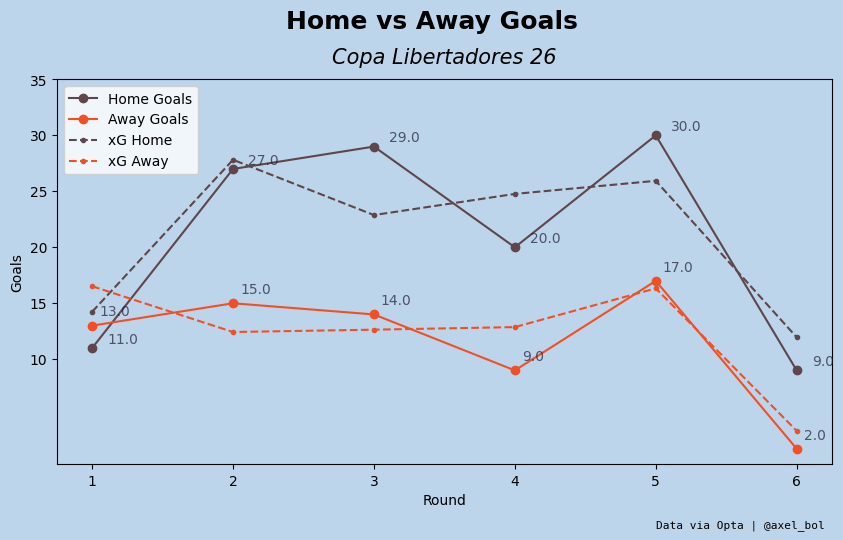

In [104]:
# line graph for home vs away goals by round

# fig, ax = plt.subplots(figsize = (10,5))
# fig.set_facecolor('#3D4849') # around color
# ax.patch.set_facecolor('#AB58B0') # middle color

plt.figure(figsize=(10, 5), facecolor="#BDD5EA")

ax = plt.gca()
ax.set_facecolor("#BDD5EA") 


plt.suptitle('Home vs Away Goals', y=1.02, horizontalalignment='center', fontweight= 'bold', fontsize= 18)
plt.title('Copa Libertadores 26',
          y = 1.02,
          loc='center',
          fontdict={
              'weight': 'roman',
              'fontsize': 15,
              'fontstyle': 'italic'
          })

plt.plot(df_goals.matchRound, df_goals.home_goals, color='#5f464b', marker='o', linestyle='-', label='Home Goals')
plt.plot(df_goals.matchRound, df_goals.away_goals, color='#f15025', marker='o', ls='-', label='Away Goals')

# xG columns
# OPTION 1 xG values as points only (scatter, no lines)
# plt.scatter(df_goals.matchRound, df_goals.xG_home,
#             color='black', marker='o', s=60, alpha=0.7,
#             label='xG Home')
# plt.scatter(df_goals.matchRound, df_goals.xG_away,
#             color='#f15025', marker='s', s=60, alpha=0.7,
#             label='xG Away')

# OPTION 2 overlay xG as dashed lines
plt.plot(df_goals.matchRound, df_goals.xG_home, 
         color="#5f464b", marker='.', linestyle='--', label='xG Home')
plt.plot(df_goals.matchRound, df_goals.xG_away, 
         color='#f15025', marker='.', linestyle='--', label='xG Away')




# Add team name labels for home goals
for i, row in df_goals.iterrows():
    plt.annotate(text=row['home_goals'],
                xy=(row['matchRound'], row['home_goals']),
                xytext=(15, 5), textcoords='offset pixels',
                fontsize=10, color='#1d1a31', alpha=0.7)
# Add team name labels for away goals
for i, row in df_goals.iterrows():
    plt.annotate(row['away_goals'], 
                (row['matchRound'], row['away_goals']),
                xytext=(5, 7), textcoords='offset points',
                fontsize=10, color='#1d1a31', alpha=0.7,)
    
# Set "x" ticks from min to max round
min_round = int(min(df_goals.matchRound))
max_round = int(max(df_goals.matchRound))
plt.xticks(ticks=range(min_round, max_round + 1, 1)) # (range(start, stop, step))

max_match = int(max(df_goals.home_goals))
plt.yticks(ticks=range(10, max_match + 10, 5))

plt.xlabel('Round')
plt.ylabel('Goals')
plt.legend()

# info

plt.text(5, -5, 'Data via Opta | @axel_bol', ha='left', fontsize=8, fontfamily='monospace')

# save img
plt.savefig(r'C:\Users\axel_\Documents\conda\images\line_home_away.png', dpi=300, bbox_inches='tight', pad_inches=0.35)

plt.show()

In [83]:
df_goals

,matchRound,home_goals,away_goals,xG_home,xG_away
0,1,11,13,14.24,16.52
1,2,27,15,27.82,12.43
2,3,29,14,22.88,12.64
3,4,20,9,24.77,12.87
4,5,30,17,25.94,16.33
5,6,9,2,11.96,3.60
